=== HOUSE PRICE PREDICTION RESULTS ===
Coefficients:
  - Square footage: $119.33 per sqft
  - Bedrooms:       $7601.57 per bedroom
  - Bathrooms:      $5178.91 per bathroom
Intercept: $53,086.90

Mean Absolute Error (MAE): $11,832.51
R² Score: 0.9876


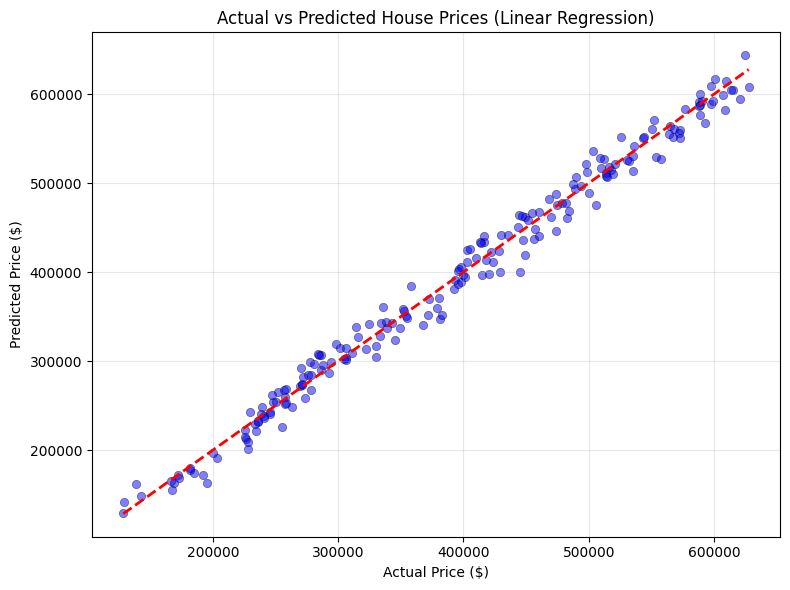

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ------------------------------------------------------------
# 1. CREATE OR LOAD DATASET
# Using a realistic synthetic dataset (or replace with your CSV)
# ------------------------------------------------------------
np.random.seed(42)
n = 1000
square_footage = np.random.randint(500, 4500, n)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 5, n)

# True relationship + noise
price = (50000 + square_footage * 120 + bedrooms * 8000 +
         bathrooms * 5000 + np.random.normal(0, 15000, n))

df = pd.DataFrame({
    'square_footage': square_footage,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'price': price
})

# If you have a real CSV file, uncomment and use:
# from google.colab import files
# uploaded = files.upload()   # upload your CSV
# df = pd.read_csv('your_file.csv')
# Make sure columns are named: square_footage, bedrooms, bathrooms, price

# ------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------
X = df[['square_footage', 'bedrooms', 'bathrooms']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------------------------------------------
# 3. TRAIN LINEAR REGRESSION
# ------------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------------------------------------
# 4. PREDICT AND EVALUATE
# ------------------------------------------------------------
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== HOUSE PRICE PREDICTION RESULTS ===")
print(f"Coefficients:")
print(f"  - Square footage: ${model.coef_[0]:.2f} per sqft")
print(f"  - Bedrooms:       ${model.coef_[1]:.2f} per bedroom")
print(f"  - Bathrooms:      ${model.coef_[2]:.2f} per bathroom")
print(f"Intercept: ${model.intercept_:,.2f}")
print(f"\nMean Absolute Error (MAE): ${mae:,.2f}")
print(f"R² Score: {r2:.4f}")

# ------------------------------------------------------------
# 5. VISUALIZATION
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', edgecolors='k', lw=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted House Prices (Linear Regression)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()